In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

from mazemods import maze
from mazemods import makeMaze
from mazemods import collisionCheck
from mazemods import makePath
from mazemods import getPathFromActions
from mazemods import getCostOfActions
from mazemods import stayWestCost
from mazemods import stayEastCost
import mediumMaze

In [45]:
n = mediumMaze.n
m = mediumMaze.m
O = mediumMaze.O

xI = (1,1)
xG = (30,16)
#xG = (10,10)
#xG = (9,9)

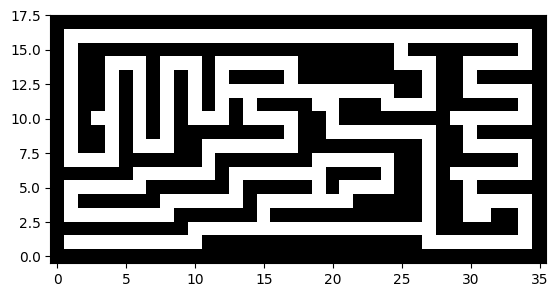

In [46]:
makeMaze(n,m,O)
maze(n,m,O)
plt.show()

In [47]:
actions = [(1,0), (0,1), (-1,0), (0,-1)]

In [48]:
def BreadthFirstSearch(xI,xG,n,m,O):
    # Problem state parameters - xI: initial state, xG: goal state
    # Problem Environment Parameters - n: number of rows, m: number of columns, O: list of obstacles
    
    # Initializing the Q and visited set and creating parent map
    Q = [(xI, [])] 
    visited_list = {xI}
    nodes_visited = 1

    while Q:
        current_state, action_list = Q.pop(0)
        if current_state == xG:
            path = getPathFromActions(xI, action_list) #path = path_from_actions(xi, action list) #need to create this path from map function
            cost_path = getCostOfActions(xI,action_list,O)
            path_to_plot = makePath(xI,xG,path,n,m,O)
            plt.imshow(path_to_plot)
            plt.gca().invert_yaxis()
            plt.show()
            #print(visited_list)
            print("The cost of the path is:", cost_path)
            print(nodes_visited," nodes were visited")
            return action_list, cost_path, nodes_visited
        else:
            for action in actions:
                next_state = (current_state[0] + action[0], current_state[1] + action[1])
                if next_state not in visited_list and not collisionCheck(current_state, action, O):
                    Q.append((next_state, action_list + [action]))
                    visited_list.add(next_state)
                    nodes_visited += 1
    if not Q:
        print("Could not find a path to goal")
        print("Current state:", current_state)
        print(nodes_visited, " nodes visited")
        #print("List of visited nodes", visited_list)
        #print("List of actions till this point", action_list)

    return action_list, None, nodes_visited

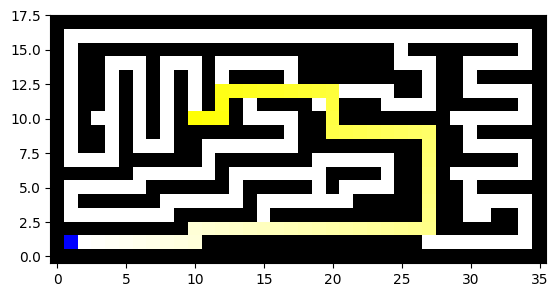

The cost of the path is: 56
171  nodes were visited


In [49]:
action_list, cost_path, nodes_visited = BreadthFirstSearch(xI,xG,n,m,O)